# **Problem Statement**

## **Business Context**

Workplace safety in hazardous environments like construction sites and industrial plants is crucial to prevent accidents and injuries. One of the most important safety measures is ensuring workers wear safety helmets, which protect against head injuries from falling objects and machinery. Non-compliance with helmet regulations increases the risk of serious injuries or fatalities, making effective monitoring essential, especially in large-scale operations where manual oversight is prone to errors and inefficiency.

To overcome these challenges, SafeGuard Corp plans to develop an automated image analysis system capable of detecting whether workers are wearing safety helmets. This system will improve safety enforcement, ensuring compliance and reducing the risk of head injuries. By automating helmet monitoring, SafeGuard aims to enhance efficiency, scalability, and accuracy, ultimately fostering a safer work environment while minimizing human error in safety oversight.

## **Objective**

As a data scientist at SafeGuard Corp, you are tasked with developing an image classification model that classifies images into one of two categories:
- **With Helmet:** Workers wearing safety helmets.
- **Without Helmet:** Workers not wearing safety helmets.

## **Data Description**

The dataset consists of **631 images**, equally divided into two categories:

- **With Helmet:** 311 images showing workers wearing helmets.
- **Without Helmet:** 320 images showing workers not wearing helmets.

**Dataset Characteristics:**
- **Variations in Conditions:** Images include diverse environments such as construction sites, factories, and industrial settings, with variations in lighting, angles, and worker postures to simulate real-world conditions.
- **Worker Activities:** Workers are depicted in different actions such as standing, using tools, or moving, ensuring robust model learning for various scenarios.

# **Installing and Importing the Necessary Libraries**

In [ ]:
!pip install tensorflow[and-cuda] numpy>=1.26 -q

In [ ]:
import tensorflow as tf
print("Num GPUs Available:", len(tf.config.list_physical_devices('GPU')))
print(tf.__version__)

Num GPUs Available: 1
2.18.0


**Note:**

- After running the above cell, kindly restart the notebook kernel (for Jupyter Notebook) or runtime (for Google Colab) and run all cells sequentially from the next cell.

- On executing the above line of code, you might see a warning regarding package dependencies. This error message can be ignored as the above code ensures that all necessary libraries and their dependencies are maintained to successfully execute the code in this notebook.

In [ ]:
import os
import random
import numpy as np                                                                               # Importing numpy for Matrix Operations
import pandas as pd
import seaborn as sns
import matplotlib.image as mpimg                                                                 # Importing pandas to read CSV files
import matplotlib.pyplot as plt                                                                  # Importting matplotlib for Plotting and visualizing images
import math                                                                                      # Importing math module to perform mathematical operations
import cv2


# Tensorflow modules
import keras
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator                              # Importing the ImageDataGenerator for data augmentation
from tensorflow.keras.models import Sequential                                                   # Importing the sequential module to define a sequential model
from tensorflow.keras.layers import Dense,Dropout,Flatten,Conv2D,MaxPooling2D,BatchNormalization # Defining all the layers to build our CNN Model
from tensorflow.keras.optimizers import Adam,SGD                                                 # Importing the optimizers which can be used in our model
from sklearn import preprocessing                                                                # Importing the preprocessing module to preprocess the data
from sklearn.model_selection import train_test_split                                             # Importing train_test_split function to split the data into train and test
from sklearn.metrics import confusion_matrix
from tensorflow.keras.models import Model
from keras.applications.vgg16 import VGG16                                               # Importing confusion_matrix to plot the confusion matrix

# Display images using OpenCV
from google.colab.patches import cv2_imshow

#Imports functions for evaluating the performance of machine learning models
from sklearn.metrics import confusion_matrix, f1_score,accuracy_score, recall_score, precision_score, classification_report
from sklearn.metrics import mean_squared_error as mse                                                 # Importing cv2_imshow from google.patches to display images

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# Set the seed using keras.utils.set_random_seed. This will set:
# 1) `numpy` seed
# 2) backend random seed
# 3) `python` random seed
tf.keras.utils.set_random_seed(812)

# **Data Overview**


##Loading the data

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
images = np.load('/content/drive/MyDrive/Colab Notebooks/CompVision/images_proj.npy') #Code to load the images
labels = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/CompVision/Labels_proj.csv') #Code to load the labels

In [ ]:
#Print the shape of images and Labels.
print(images.shape)
print(labels.shape)

(631, 200, 200, 3)
(631, 1)


# **Exploratory Data Analysis**

###Plot random images from each of the classes and print their corresponding labels.

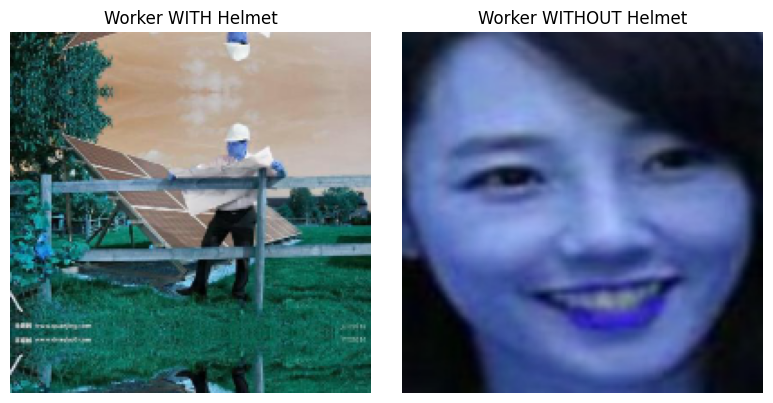

In [ ]:
helmet_indices = np.where(labels == 1)[0]
no_helmet_indices = np.where(labels == 0)[0]

# Select one image from each class
helmet_img = images[np.random.choice(helmet_indices)]
no_helmet_img = images[np.random.choice(no_helmet_indices)]

# Plot the images
fig, axes = plt.subplots(1, 2, figsize=(8, 4))

# Display "With Helmet" image
axes[0].imshow(helmet_img)
axes[0].set_title("Worker WITH Helmet")
axes[0].axis('off')

# Display "Without Helmet" image
axes[1].imshow(no_helmet_img)
axes[1].set_title("Worker WITHOUT Helmet")
axes[1].axis('off')

# Show the plots
plt.tight_layout()
plt.show()

## Checking for class imbalance


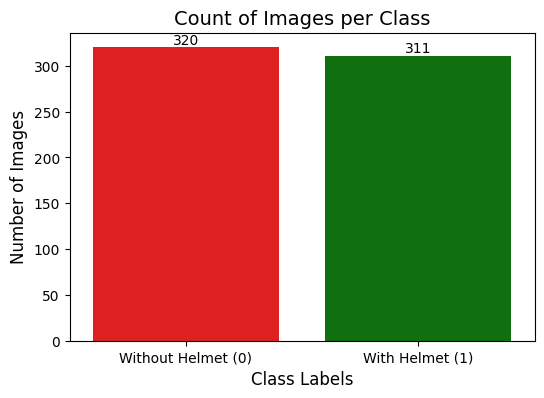

In [ ]:
# Create a count plot
plt.figure(figsize=(6, 4))
ax = sns.countplot(x=labels.iloc[:, 0], palette=['red', 'green'])

# Add exact counts on top of bars
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom', fontsize=10, )

# Add labels
plt.xlabel("Class Labels", fontsize=12)
plt.ylabel("Number of Images", fontsize=12)
plt.title("Count of Images per Class", fontsize=14)
plt.xticks(ticks=[0, 1], labels=["Without Helmet (0)", "With Helmet (1)"])  # Rename x-axis labels

# Show plot
plt.show()

***Observations***

a) The dataset contains 631 images, split almost equally between "With Helmet" (311 images) and "Without Helmet" (320 images), indicating a balanced dataset.

b) Sample images from each class were successfully displayed.
The class distribution plot confirms the near-equal distribution of images in both categories, suggesting no significant class imbalance.


# **Data Preprocessing**

## Converting images to grayscale

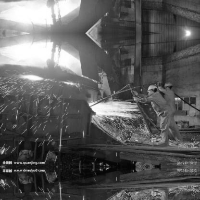

In [ ]:
images_gray = []
for i in range(len(images)):
    img_gray = cv2.cvtColor(images[i], cv2.COLOR_BGR2GRAY)  # Convert to grayscale
    images_gray.append(img_gray)

# Display a sample grayscale image
n = 5
cv2_imshow(images_gray[n])

***Observations***

The images were successfully converted to grayscale, and a sample grayscale image was displayed.

### Splitting the dataset



- As we have less images in our dataset, we will only use 10% of our data for testing, 10% of our data for validation and 80% of our data for training.
- We are using the `train_test_split()` function from scikit-learn. Here, we split the dataset into three parts, train,test and validation.

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_temp, y_train, y_temp = train_test_split(np.array(images),labels , test_size=0.2, random_state=42,stratify=labels)
X_val, X_test, y_val, y_test = train_test_split(X_temp,y_temp , test_size=0.5, random_state=42,stratify=y_temp)

In [ ]:
print(X_train.shape,y_train.shape) #Code to print the shape of the train data
print(X_val.shape,y_val.shape) #Code to print the shape of the validation data
print(X_test.shape,y_test.shape) #Code to print the shape of the test data

(504, 200, 200, 3) (504, 1)
(63, 200, 200, 3) (63, 1)
(64, 200, 200, 3) (64, 1)


### Data Normalization

Since the **image pixel values range from 0-255**, our method of normalization here will be **scaling** - we shall **divide all the pixel values by 255 to standardize the images to have values between 0-1.**

In [ ]:
X_train_normalized = X_train.astype('float32')/255.0 #Code to normalize the training images
X_val_normalized = X_val.astype('float32')/255.0  #Code to normalize the validation images
X_test_normalized = X_test.astype('float32')/255.0   #Code to normalize the test images

In [ ]:
print(X_train_normalized.shape)
print(X_val_normalized.shape)
print(X_test_normalized.shape)

(504, 200, 200, 3)
(63, 200, 200, 3)
(64, 200, 200, 3)


# **Model Building**

##Model Evaluation Criterion

***Evaluation Metrics:***

a) **Accuracy:** Overall classification performance.

b) **Precision:** Minimize false positives (incorrectly flagging helmet presence).

c) **Recall:** Minimize false negatives (missing workers without helmets)

d) **F1-Score:** Balanced measure for binary classification.

The two important metrics in the context of workplace safety and helmet detection, **Recall** is particularly important. A high recall means the model is good at identifying workers with helmets. Failing to detect a worker with a helmet (a false negative) is less critical than failing to detect a worker without a helmet (also a false negative in this binary classification, but the 'positive' class is 'With Helmet').

**Accuracy** is also important as a general measure of correctness, indicating the overall proportion of images that were correctly classified.

***Model Criteria***

For the 4 CNN models we will be using the original images (BGR) as **input_shape** for image classification.

**Reasons:**

a) **Rich Information:** Color images contain more information than grayscale images. The different color channels capture distinct aspects of the image, which can be crucial for distinguishing between objects or classes.

b) **Feature Extraction:** CNNs learn hierarchical features from the input data. The initial layers learn basic features like edges and corners, and deeper layers combine these to learn more complex patterns. Color information provides additional dimensions for the network to learn from, potentially leading to more robust and discriminative features.

c) **Pre-trained Models:** Many powerful pre-trained CNN models (like VGG16 used in Models 2, 3, and 4) were originally trained on large datasets of color images (like ImageNet, which is RGB). Using 3-channel color images as input allows to directly leverage the features learned by these pre-trained models through transfer learning, which can significantly improve performance, especially on smaller datasets.

## Utility Functions

In [ ]:
# defining a function to compute different metrics to check performance of a classification model built using statsmodels
def model_performance_classification(model, predictors, target):
    """
    Function to compute different metrics to check classification model performance

    model: classifier
    predictors: independent variables
    target: dependent variable
    """

    # checking which probabilities are greater than threshold
    pred = model.predict(predictors).reshape(-1)>0.5

    target = target.to_numpy().reshape(-1)


    acc = accuracy_score(target, pred)  # to compute Accuracy
    recall = recall_score(target, pred, average='weighted')  # to compute Recall
    precision = precision_score(target, pred, average='weighted')  # to compute Precision
    f1 = f1_score(target, pred, average='weighted')  # to compute F1-score

    # creating a dataframe of metrics
    df_perf = pd.DataFrame({"Accuracy": acc, "Recall": recall, "Precision": precision, "F1 Score": f1,},index=[0],)

    return df_perf

In [ ]:
def plot_confusion_matrix(model,predictors,target,ml=False):
    """
    Function to plot the confusion matrix

    model: classifier
    predictors: independent variables
    target: dependent variable
    ml: To specify if the model used is an sklearn ML model or not (True means ML model)
    """

    # checking which probabilities are greater than threshold
    pred = model.predict(predictors).reshape(-1)>0.5

    target = target.to_numpy().reshape(-1)

    # Plotting the Confusion Matrix using confusion matrix() function which is also predefined tensorflow module
    confusion_matrix = tf.math.confusion_matrix(target,pred)
    f, ax = plt.subplots(figsize=(10, 8))
    sns.heatmap(
        confusion_matrix,
        annot=True,
        linewidths=.4,
        fmt="d",
        square=True,
        ax=ax
    )
    plt.show()

##Model 1: Simple Convolutional Neural Network (CNN)

In [ ]:
# Initializing Model
model_1 = Sequential()

# Convolutional layers
model_1.add(Conv2D(32, (3, 3), activation='relu', padding="same", input_shape=(200,200,3))) #Code to define the shape of the input image
model_1.add(MaxPooling2D((4, 4), padding='same'))
model_1.add(Conv2D(64, (3, 3), activation='relu', padding="same")) #Code to define the number of output channels,the kernel shape and the activation function
model_1.add(MaxPooling2D((2, 2), padding='same')) #Code to define the shape of the pooling kernel
model_1.add(Conv2D(128, (3, 3), activation='relu', padding="same")) #Code to define the number of output channels,the kernel shape and the activation function

# Flatten and Dense layers
model_1.add(Flatten())
model_1.add(Dense(4, activation='relu'))
model_1.add(Dense(1, activation='sigmoid'))  #Code to define the number of neurons in the output layer and the activation function

# Compile with Adam Optimizer Model 1
opt = Adam(learning_rate=0.001) #Code to define the learning rate.
model_1.compile(optimizer=opt, loss='binary_crossentropy', metrics=["accuracy","Recall"])

# Model 1 Summary
model_1.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 200, 200, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 50, 50, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 50, 50, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 25, 25, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 25, 25, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 80000)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4)              │       320,004 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 413,257 (1.58 MB)

 Trainable params: 413,257 (1.58 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Train Model 1
history_1 = model_1.fit(
            X_train_normalized, y_train,
            epochs=20,
            validation_data=(X_val_normalized,y_val),
            shuffle=True,
            batch_size=32,
            verbose=2
)

Epoch 1/20
16/16 - 11s - 678ms/step - Recall: 0.8911 - accuracy: 0.7143 - loss: 0.6448 - val_Recall: 0.7742 - val_accuracy: 0.8889 - val_loss: 0.4746
Epoch 2/20
16/16 - 0s - 28ms/step - Recall: 0.9556 - accuracy: 0.9544 - loss: 0.2994 - val_Recall: 0.9032 - val_accuracy: 0.9524 - val_loss: 0.1681
Epoch 3/20
16/16 - 1s - 38ms/step - Recall: 0.9274 - accuracy: 0.9385 - loss: 0.2332 - val_Recall: 0.6129 - val_accuracy: 0.8095 - val_loss: 0.6174
Epoch 4/20
16/16 - 0s - 29ms/step - Recall: 0.9677 - accuracy: 0.9702 - loss: 0.1157 - val_Recall: 0.9677 - val_accuracy: 0.9841 - val_loss: 0.0606
Epoch 5/20
16/16 - 0s - 27ms/step - Recall: 0.9879 - accuracy: 0.9881 - loss: 0.0811 - val_Recall: 1.0000 - val_accuracy: 1.0000 - val_loss: 0.0075
Epoch 6/20
16/16 - 0s - 28ms/step - Recall: 0.9758 - accuracy: 0.9841 - loss: 0.0589 - val_Recall: 1.0000 - val_accuracy: 1.0000 - val_loss: 0.0081
Epoch 7/20
16/16 - 1s - 40ms/step - Recall: 0.9960 - accuracy: 0.9960 - loss: 0.0130 - val_Recall: 1.0000 - va

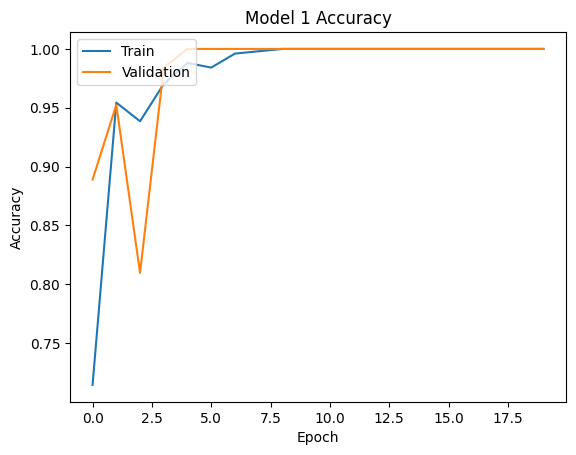

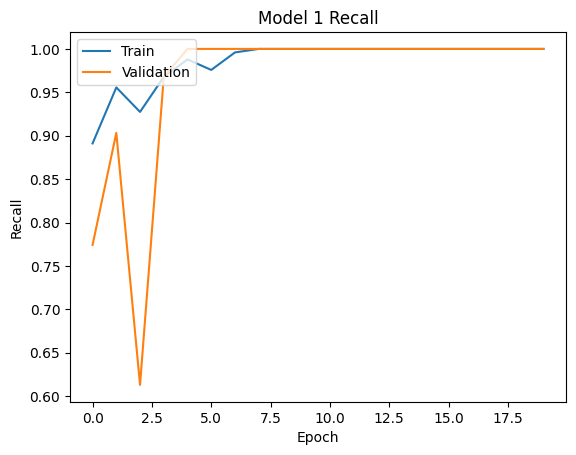

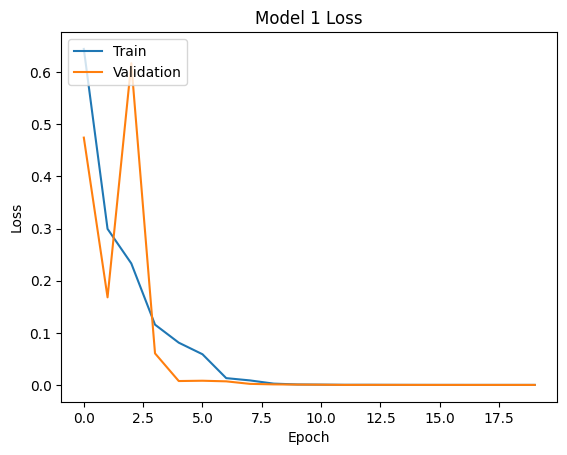

In [ ]:
# Plotting accuracy
plt.plot(history_1.history['accuracy']) #Code to plot the train metrics
plt.plot(history_1.history['val_accuracy']) #Code to plot the validation data metrics
plt.title('Model 1 Accuracy') #Code to define the title for the plot
plt.ylabel('Accuracy') #Code to define the label for the y-axis
plt.xlabel('Epoch') #Code to define the label for the x-axis
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

# Plotting Recall
plt.plot(history_1.history['Recall']) #Code to plot the train metrics
plt.plot(history_1.history['val_Recall']) #Code to plot the validation data metrics
plt.title('Model 1 Recall') #Code to define the title for the plot
plt.ylabel('Recall') #Code to define the label for the y-axis
plt.xlabel('Epoch') #Code to define the label for the x-axis
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

# Plotting loss
plt.plot(history_1.history['loss']) #Code to plot the train metrics
plt.plot(history_1.history['val_loss']) #Code to plot the validation data metrics
plt.title('Model 1 Loss') #Code to define the title for the plot
plt.ylabel('Loss') #Code to define the label for the y-axis
plt.xlabel('Epoch') #Code to define the label for the x-axis
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

***Observations***

**Accuracy Plot:** Both the training and validation accuracy start relatively low but increase rapidly over the epochs. They quickly converge and reach near 100% accuracy on both the training and validation sets, indicating that the model is performing very well on the data it has seen during training and validation.

**Recall Plot:** Similar to accuracy, the training and validation recall also improve significantly and reach very high values (close to 100%) on both sets. This indicates that Model 1 is very effective at identifying instances of the positive class ("With Helmet").

**Loss Plot:** The training and validation loss decrease rapidly and converge to very low values. This shows that the model is effectively learning to minimize the error between its predictions and the true labels on both the training and validation data.

In [ ]:
# Evaluate Training performance metrics
model_1_train_perf = model_performance_classification(model_1, X_train_normalized,y_train)

print("Train performance metrics")
print(model_1_train_perf)

16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step
Train performance metrics
   Accuracy  Recall  Precision  F1 Score
0       1.0     1.0        1.0       1.0


16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step


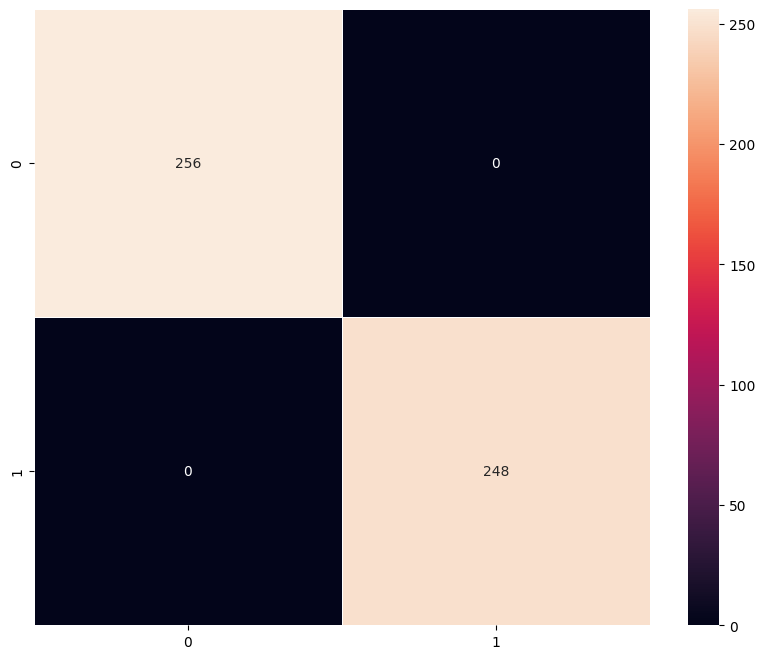

In [ ]:
# Plotting Confusion Matrix
plot_confusion_matrix(model_1,X_train_normalized,y_train)

***Observations:***

a) The **Model 1 Training performance metrics**  indicates that Model 1 achieved perfect scores on the training dataset for all evaluated metrics.

b) **Model 1 Training Confusion Matrix:** This confusion matrix confirms that Model 1 correctly classified all 256 instances of "Without Helmet" and all 248 instances of "With Helmet" in the training dataset. There were no false positives or false negatives.

In [ ]:
# Evaluate Validation performance metrics
model_1_valid_perf = model_performance_classification(model_1, X_val_normalized,y_val)

print("Validation performance metrics")
print(model_1_valid_perf)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 210ms/step
Validation performance metrics
   Accuracy  Recall  Precision  F1 Score
0       1.0     1.0        1.0       1.0


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step


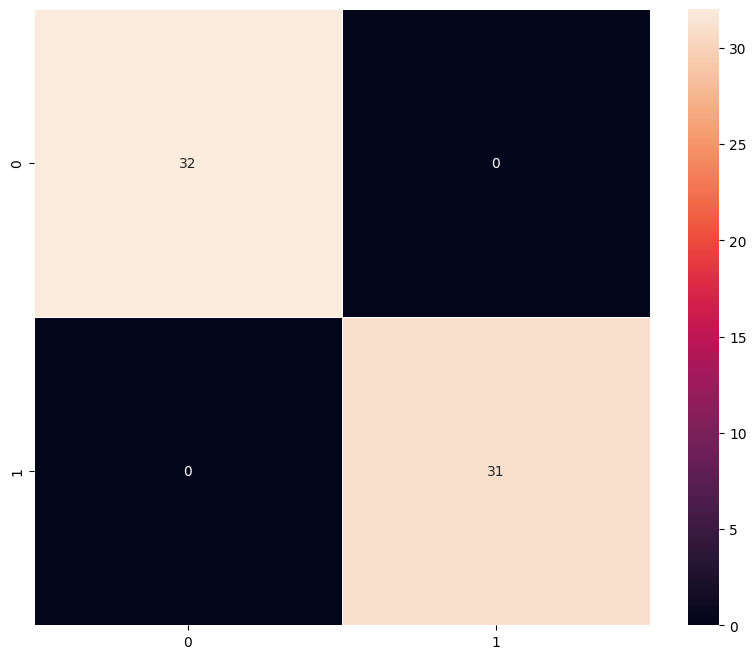

In [ ]:
# Plotting Confusion Matrix
plot_confusion_matrix(model_1,X_val_normalized,y_val)

***Observations:***

a) The **Model 1 Validation performance metrics** indicates that Model 1 achieved perfect scores on the training dataset for all evaluated metrics.

b) **Model 1 Validation Confusion Matrix:** This confusion matrix confirms that Model 1 correctly classified all 32 instances of "Without Helmet" and all 31 instances of "With Helmet" in the training dataset. There were no false positives or false negatives.

### Vizualizing the predictions

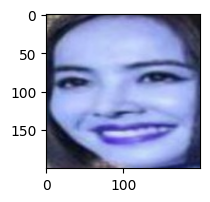

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 643ms/step
Predicted Label: 0
True Label: 0


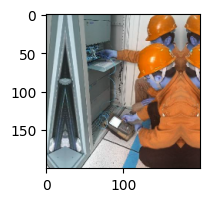

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
Predicted Label: 1
True Label: 1


In [ ]:
# For index 15
plt.figure(figsize=(2,2))
plt.imshow(X_val[15])
plt.show()
prediction = model_1.predict(X_val_normalized[15].reshape(1,200,200,3))
predicted_label = prediction[0][0]>0.5  # Extract the predicted class label
print('Predicted Label:', 1 if predicted_label else 0)
true_label = y_val.iloc[15]['Label']
print('True Label:', true_label)

# For index 10
plt.figure(figsize=(2,2))
plt.imshow(X_val[10])
plt.show()
prediction = model_1.predict(X_val_normalized[10].reshape(1,200,200,3))
predicted_label = prediction[0][0]>0.5  # Extract the predicted class label
print('Predicted Label:', 1 if predicted_label else 0)
true_label = y_val.iloc[10]['Label']
print('True Label:', true_label)

***Observations:***

Model 1 is correctly predicting and classifying the "Without Helmet" and "With Helmet" sample images.

## Model 2: (VGG-16 (Base))

In [ ]:
vgg_model = VGG16(weights='imagenet',include_top=False,input_shape=(200,200,3)) #Code to define the shape of the image
vgg_model.summary()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 200, 200, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 200, 200, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 200, 200, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 100, 100, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 100, 100, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 100, 100, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 50, 50, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 50, 50, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 50, 50, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 50, 50, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 25, 25, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 25, 25, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 25, 25, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 25, 25, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 12, 12, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 12, 12, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 12, 12, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 12, 12, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 6, 6, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 14,714,688 (56.13 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Making all the layers of the VGG model non-trainable. i.e. freezing them
for layer in vgg_model.layers:
    layer.trainable = False

In [ ]:
model_2 = Sequential()

# Adding the convolutional part of the VGG16 model from above
model_2.add(vgg_model)

# Flattening the output of the VGG16 model because it is from a convolutional layer
model_2.add(Flatten())

# Adding a dense output layer
model_2.add(Dense(1, activation='sigmoid')) #Code to define the number of neurons in the output layer.

# Compile with Adam Optimizer Model 2
opt = Adam(learning_rate=0.001) #Code to define the learning rate.
model_2.compile(optimizer=opt, loss=keras.losses.BinaryCrossentropy(), metrics=["accuracy","Recall"])

# Model 2 Summary
model_2.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 6, 6, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 18432)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │        18,433 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,733,121 (56.20 MB)

 Trainable params: 18,433 (72.00 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [ ]:
train_datagen = ImageDataGenerator()

In [ ]:
# Epochs
epochs = 20
# Batch size
batch_size = 32

# Train Model 2
history_2 = model_2.fit(train_datagen.flow(X_train_normalized,y_train,
                                      batch_size=batch_size,
                                      seed=42,
                                      shuffle=False),
                    epochs=epochs,
                    steps_per_epoch=X_train_normalized.shape[0] // batch_size,
                    validation_data=(X_val_normalized,y_val),
                    verbose=1)

Epoch 1/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 35s 2s/step - Recall: 0.7316 - accuracy: 0.6953 - loss: 0.5185 - val_Recall: 1.0000 - val_accuracy: 1.0000 - val_loss: 0.0276
Epoch 2/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - Recall: 1.0000 - accuracy: 1.0000 - loss: 0.0401 - val_Recall: 1.0000 - val_accuracy: 1.0000 - val_loss: 0.0262
Epoch 3/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 10s 196ms/step - Recall: 1.0000 - accuracy: 1.0000 - loss: 0.0208 - val_Recall: 1.0000 - val_accuracy: 1.0000 - val_loss: 0.0051
Epoch 4/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - Recall: 1.0000 - accuracy: 1.0000 - loss: 0.0105 - val_Recall: 1.0000 - val_accuracy: 1.0000 - val_loss: 0.0049
Epoch 5/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 221ms/step - Recall: 1.0000 - accuracy: 1.0000 - loss: 0.0039 - val_Recall: 1.0000 - val_accuracy: 1.0000 - val_loss: 0.0045
Epoch 6/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - Recall: 1.0000 - accuracy: 1.0000 - loss: 0.0039 - val_Recall: 1.0000 - val_accuracy: 1.0000 - val_loss: 0.0044
Epoch 7/

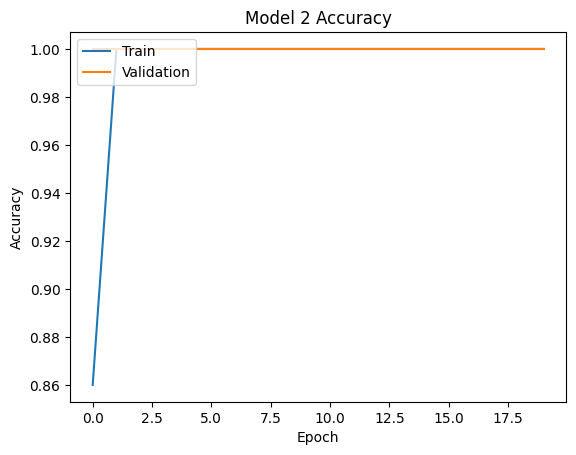

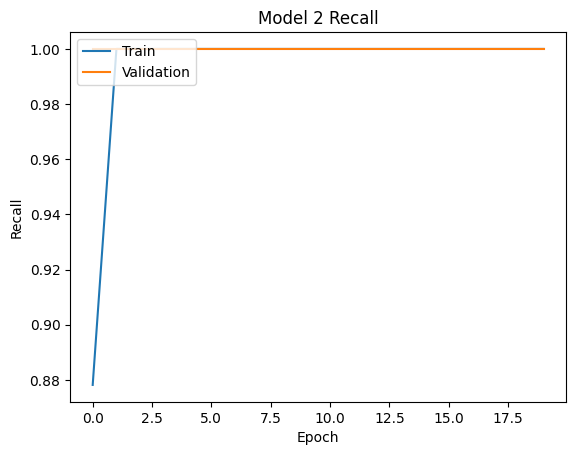

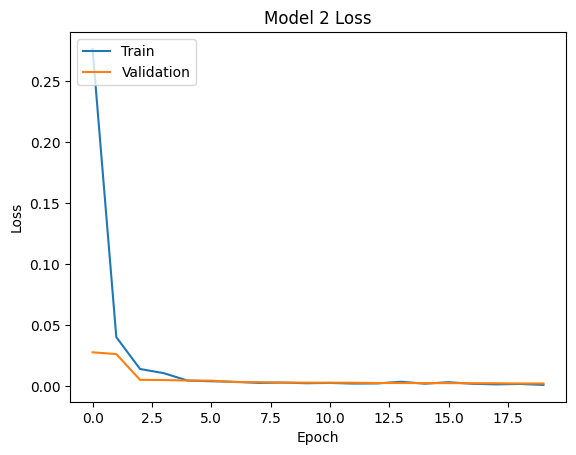

In [ ]:
# Plotting accuracy
plt.plot(history_2.history['accuracy']) #Code to plot the train metrics
plt.plot(history_2.history['val_accuracy']) #Code to plot the validation data metrics
plt.title('Model 2 Accuracy') #Code to define the title for the plot
plt.ylabel('Accuracy') #Code to define the label for the y-axis
plt.xlabel('Epoch') #Code to define the label for the x-axis
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

# Plotting Recall
plt.plot(history_2.history['Recall']) #Code to plot the train metrics
plt.plot(history_2.history['val_Recall']) #Code to plot the validation data metrics
plt.title('Model 2 Recall') #Code to define the title for the plot
plt.ylabel('Recall') #Code to define the label for the y-axis
plt.xlabel('Epoch') #Code to define the label for the x-axis
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

# Plotting loss
plt.plot(history_2.history['loss']) #Code to plot the train metrics
plt.plot(history_2.history['val_loss']) #Code to plot the validation data metrics
plt.title('Model 2 Loss') #Code to define the title for the plot
plt.ylabel('Loss') #Code to define the label for the y-axis
plt.xlabel('Epoch') #Code to define the label for the x-axis
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

***Observations:***

**Accuracy Plot:** The training and validation accuracy for Model 2 start at a moderate level and quickly increase, converging to near 100% accuracy on both datasets within the first few epochs. This indicates that the pre-trained VGG-16 base, even with only a simple dense layer on top, is very effective at learning to classify the images.

**Recall Plot:** The training and validation Recall plots show a similar trend to accuracy, starting at a moderate value and rapidly increasing to 100% within a few epochs. This suggests that Model 2 is also highly effective at identifying the positive class ("With Helmet").

**Loss Plot:** The training and validation loss for Model 2 decrease rapidly and converge to very low values, similar to Model 1. This indicates that the model is effectively minimizing the error during training and performing well on the validation set.

In [ ]:
# Evaluate Training performance metrics
model_2_train_perf = model_performance_classification(model_2,X_train_normalized,y_train)

print("Train performance metrics")
print(model_2_train_perf)

16/16 ━━━━━━━━━━━━━━━━━━━━ 4s 247ms/step
Train performance metrics
   Accuracy  Recall  Precision  F1 Score
0       1.0     1.0        1.0       1.0


16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 175ms/step


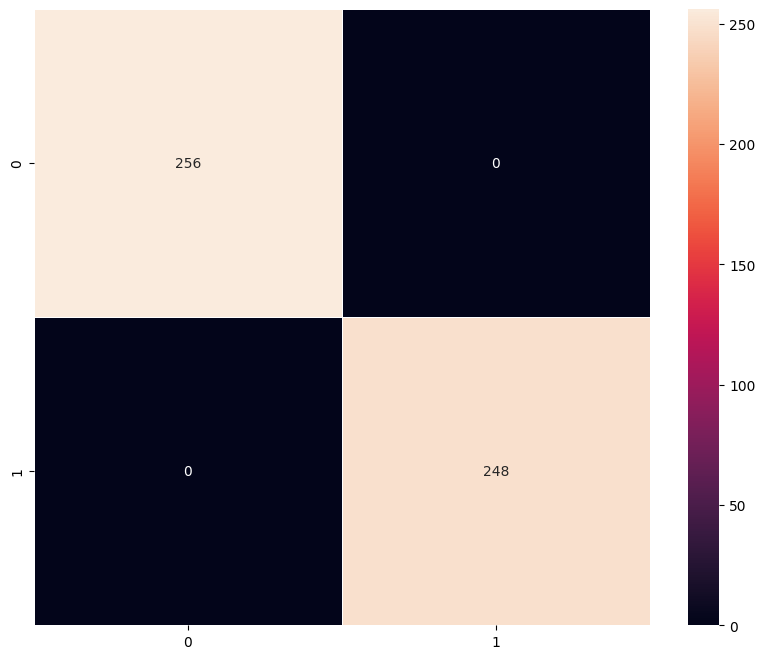

In [ ]:
# Plotting Confusion Matrix
plot_confusion_matrix(model_2,X_train_normalized,y_train)

***Observations:***

a) The **Model 2 Train performance metrics** indicates that Model 2 achieved perfect scores on the training dataset for all evaluated metrics.

b) **Model 2 Training Confusion Matrix:** This confusion matrix confirms that Model 2 correctly classified all 256 instances of "Without Helmet" and all 248 instances of "With Helmet" in the training dataset. There were no false positives or false negatives.

In [ ]:
# Evaluate Validation performance metrics
model_2_valid_perf = model_performance_classification(model_2, X_val_normalized,y_val)

print("Validation performance metrics")
print(model_2_valid_perf)

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 488ms/step
Validation performance metrics
   Accuracy  Recall  Precision  F1 Score
0       1.0     1.0        1.0       1.0


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 173ms/step


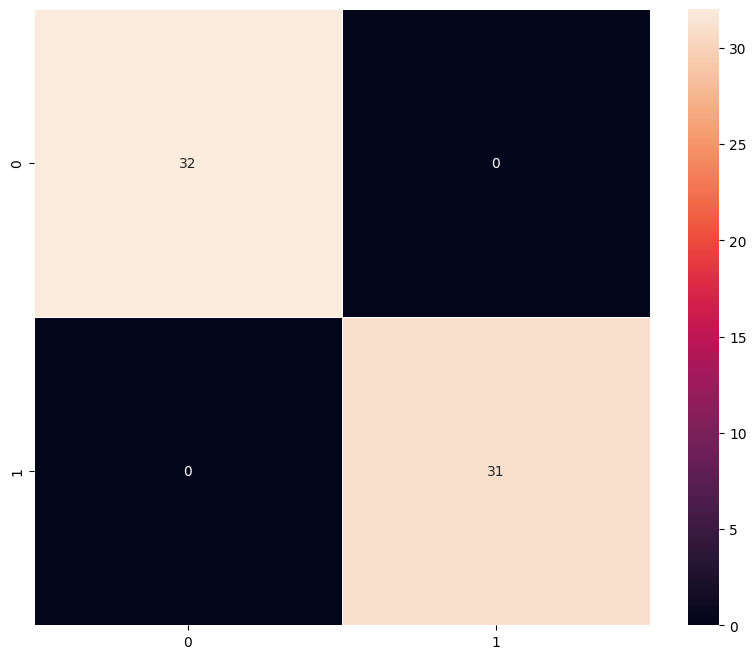

In [ ]:
# Plotting Confusion Matrix
plot_confusion_matrix(model_2,X_val_normalized,y_val)

***Observations:***

a) The **Model 2 Validation performance metrics** indicates that Model 2 achieved perfect scores on the training dataset for all evaluated metrics.

b) **Model 2 Validation Confusion Matrix:** This confusion matrix confirms that Model 2 correctly classified all 32 instances of "Without Helmet" and all 31 instances of "With Helmet" in the training dataset. There were no false positives or false negatives.

### Visualizing the prediction:

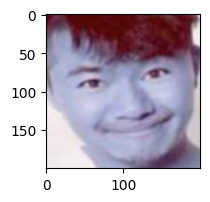

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Predicted Label: 0
True Label: 0


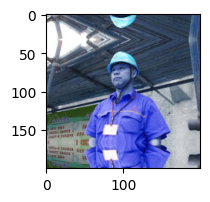

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
Predicted Label: 1
True Label: 1


In [ ]:
# For index 5
plt.figure(figsize=(2,2))
plt.imshow(X_val[5]) #Code to define the index
plt.show()
prediction = model_2.predict(X_val_normalized[5].reshape(1,200,200,3)) #Complete the code to define the index
predicted_label = prediction[0][0]>0.5  # Extract the predicted class label
print('Predicted Label:', 1 if predicted_label else 0)
true_label = y_val.iloc[5]['Label'] #Code to define the index
print('True Label:', true_label)

# For index 25
plt.figure(figsize=(2,2))
plt.imshow(X_val[25]) #Code to define the index
plt.show()
prediction = model_2.predict(X_val_normalized[25].reshape(1,200,200,3)) #Complete the code to define the index
predicted_label = prediction[0][0]>0.5  # Extract the predicted class label
print('Predicted Label:', 1 if predicted_label else 0)
true_label = y_val.iloc[25]['Label'] #Code to define the index
print('True Label:', true_label)

***Observations:***

Model 2 is correctly predicting and classifying the "Without Helmet" and "With Helmet" sample images.

## Model 3: (VGG-16 (Base + FFNN))

In [ ]:
model_3 = Sequential()

# Adding the convolutional part of the VGG16 model from above
model_3.add(vgg_model)

# Flattening the output of the VGG16 model because it is from a convolutional layer
model_3.add(Flatten())

#Adding the Feed Forward neural network
model_3.add(Dense(256,activation='relu')) #Code to define the number of neurons and the activation function
model_3.add(Dropout(rate=0.5)) #Code to define the dropout rate
model_3.add(Dense(128,activation='relu')) #Code to define the number of neurons and the activation function

# Adding a dense output layer
model_3.add(Dense(1, activation='sigmoid')) #Code to define the number of neurons in the output layer and the activation function

# Compile with Adam Optimizer Model 3
opt=Adam(learning_rate=0.001)
model_3.compile(optimizer=opt, loss=keras.losses.BinaryCrossentropy(), metrics=["accuracy","Recall"])

# Model 3 Summary
model_3.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 6, 6, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 18432)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │     4,718,848 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,466,561 (74.26 MB)

 Trainable params: 4,751,873 (18.13 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [ ]:
# Train Model 3
history_3 = model_3.fit(train_datagen.flow(X_train_normalized, y_train,
                                      batch_size=batch_size,
                                      seed=42,
                                      shuffle=False),
                    epochs=epochs,
                    steps_per_epoch=X_train_normalized.shape[0] // batch_size,
                    validation_data=(X_val_normalized,y_val),
                    verbose=1)

Epoch 1/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 9s 417ms/step - Recall: 0.7057 - accuracy: 0.7610 - loss: 0.4801 - val_Recall: 1.0000 - val_accuracy: 1.0000 - val_loss: 7.6241e-05
Epoch 2/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - Recall: 1.0000 - accuracy: 0.9688 - loss: 0.0306 - val_Recall: 1.0000 - val_accuracy: 1.0000 - val_loss: 3.2413e-05
Epoch 3/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 219ms/step - Recall: 1.0000 - accuracy: 0.9960 - loss: 0.0076 - val_Recall: 1.0000 - val_accuracy: 1.0000 - val_loss: 2.7278e-04
Epoch 4/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - Recall: 0.9375 - accuracy: 0.9688 - loss: 0.1190 - val_Recall: 1.0000 - val_accuracy: 1.0000 - val_loss: 9.8797e-05
Epoch 5/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 4s 219ms/step - Recall: 0.9947 - accuracy: 0.9970 - loss: 0.0076 - val_Recall: 1.0000 - val_accuracy: 1.0000 - val_loss: 3.9916e-05
Epoch 6/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - Recall: 1.0000 - accuracy: 1.0000 - loss: 2.2478e-04 - val_Recall: 1.0000 - val_accuracy: 1.0000 - 

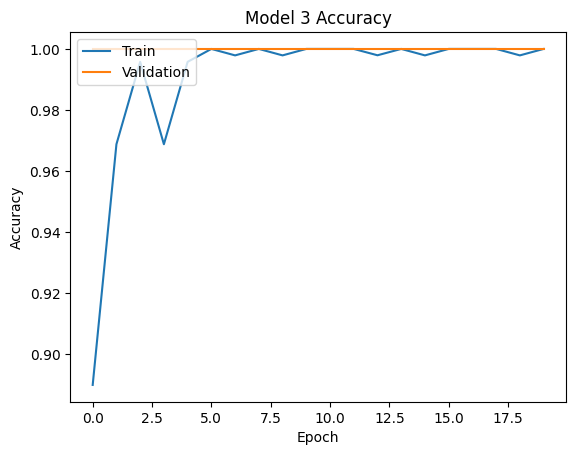

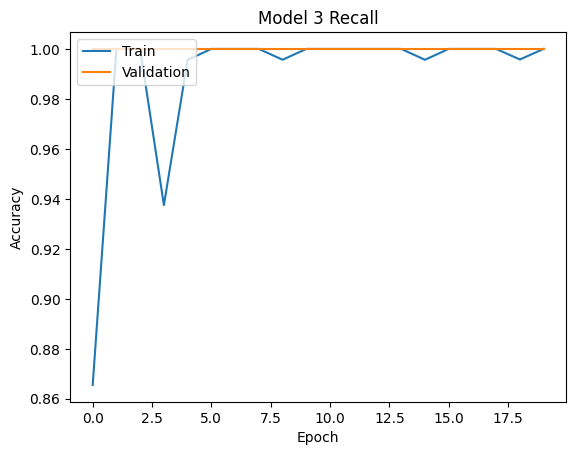

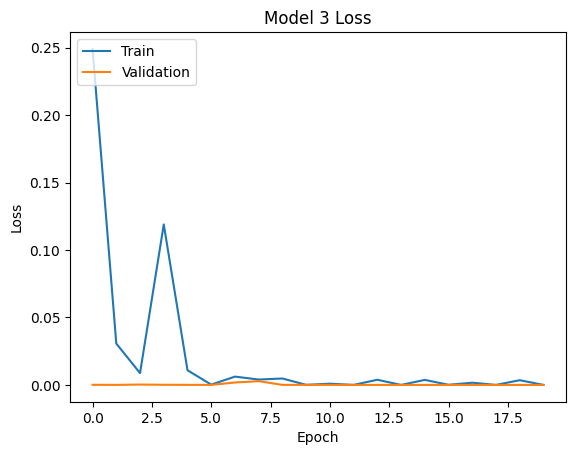

In [ ]:
# Plotting accuracy
plt.plot(history_3.history['accuracy'])
plt.plot(history_3.history['val_accuracy'])
plt.title('Model 3 Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

# Plotting Recall
plt.plot(history_3.history['Recall'])
plt.plot(history_3.history['val_Recall'])
plt.title('Model 3 Recall')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

# Plotting loss
plt.plot(history_3.history['loss'])
plt.plot(history_3.history['val_loss'])
plt.title('Model 3 Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()



***Observations:***

**Accuracy Plot:** The training and validation accuracy for Model 3 start at a moderate level and quickly increase, converging to near 100% accuracy on both datasets within the first few epochs. This indicates that the pre-trained VGG-16 base combined with the additional feed-forward layers is very effective at learning to classify the images.

**Recall Plot:** The training and validation Recall plots show a similar trend to accuracy, starting at a moderate value and rapidly increasing to 100% within a few epochs. This suggests that Model 3 is also highly effective at identifying the positive class ("With Helmet").

**Loss Plot:** The training and validation loss for Model 3 decrease rapidly and converge to very low values, similar to Models 1 and 2. This indicates that the model is effectively minimizing the error during training and performing well on the validation set.

In [ ]:
# Evaluate Training performance metrics
model_3_train_perf = model_performance_classification(model_3, X_train_normalized, y_train)
print("Model 3 Train performance metrics")
print(model_3_train_perf)

16/16 ━━━━━━━━━━━━━━━━━━━━ 4s 222ms/step
Model 3 Train performance metrics
   Accuracy  Recall  Precision  F1 Score
0       1.0     1.0        1.0       1.0


16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 174ms/step


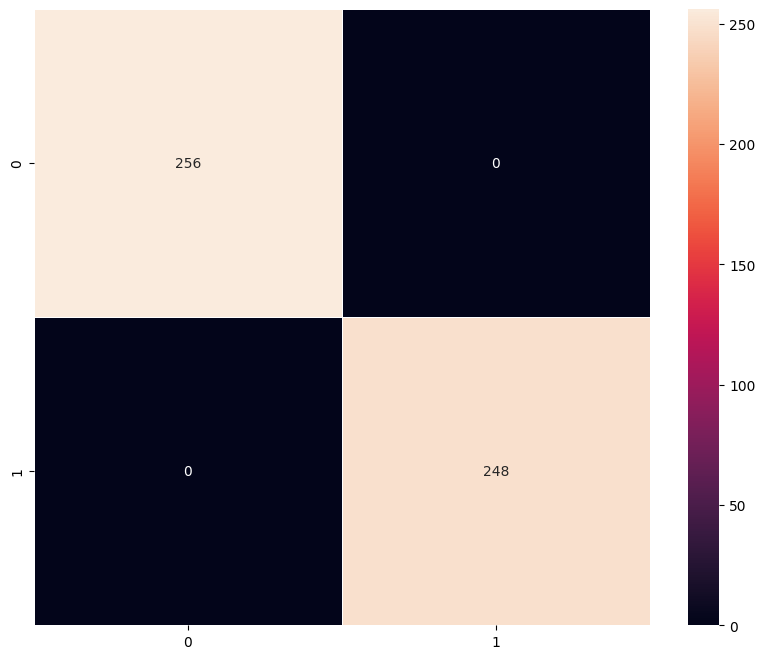

In [ ]:
# Plotting Confusion Matrix
plot_confusion_matrix(model_3, X_train_normalized, y_train)

***Observations:***

a) The **Model 3 Train performance metrics** indicates that Model 3 achieved perfect scores on the training dataset for all evaluated metrics.

b) **Model 3 Training Confusion Matrix:** This confusion matrix confirms that Model 3 correctly classified all 256 instances of "Without Helmet" and all 248 instances of "With Helmet" in the training dataset. There were no false positives or false negatives.

In [ ]:
# Evaluate Validation performance metrics
model_3_valid_perf = model_performance_classification(model_3, X_val_normalized, y_val)
print("Model 3 Validation performance metrics")
print(model_3_valid_perf)

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 510ms/step
Model 3 Validation performance metrics
   Accuracy  Recall  Precision  F1 Score
0       1.0     1.0        1.0       1.0


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 174ms/step


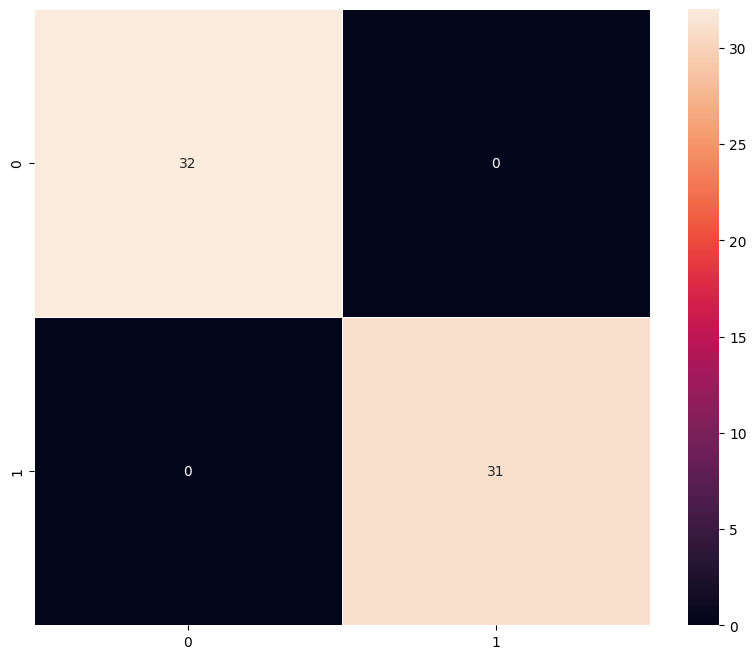

In [ ]:
# Plotting Confusion Matrix
plot_confusion_matrix(model_3, X_val_normalized, y_val)

***Observations:***

a) The **Model 3 Validation performance metrics** indicates that Model 3 achieved perfect scores on the training dataset for all evaluated metrics.

b) **Model 3 Validation Confusion Matrix:** This confusion matrix confirms that Model3 correctly classified all 32 instances of "Without Helmet" and all 31 instances of "With Helmet" in the training dataset. There were no false positives or false negatives.

#### Visualizing the predictions

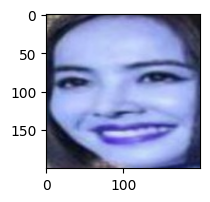

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
Predicted Label: 0
True Label: 0


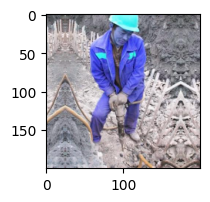

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
Predicted Label: 1
True Label: 1


In [ ]:
# For index 15
plt.figure(figsize=(2,2))
plt.imshow(X_val[15]) #Code to define the index
plt.show()
prediction = model_2.predict(X_val_normalized[15].reshape(1,200,200,3)) #Code to define the index
predicted_label = prediction[0][0]>0.5  # Extract the predicted class label
print('Predicted Label:', 1 if predicted_label else 0)
true_label = y_val.iloc[15]['Label'] #Code to define the index
print('True Label:', true_label)

# For index 50
plt.figure(figsize=(2,2))
plt.imshow(X_val[50]) #Code to define the index
plt.show()
prediction = model_2.predict(X_val_normalized[50].reshape(1,200,200,3)) #Code to define the index
predicted_label = prediction[0][0]>0.5  # Extract the predicted class label
print('Predicted Label:', 1 if predicted_label else 0)
true_label = y_val.iloc[50]['Label'] #Code to define the index
print('True Label:', true_label)

***Observations:***

Model 3 is correctly predicting and classifying the "Without Helmet" and "With Helmet" sample images.

## Model 4: (VGG-16 (Base + FFNN + Data Augmentation)

- In most of the real-world case studies, it is challenging to acquire a large number of images and then train CNNs.
- To overcome this problem, one approach we might consider is **Data Augmentation**.
- CNNs have the property of **translational invariance**, which means they can recognise an object even if its appearance shifts translationally in some way. - Taking this attribute into account, we can augment the images using the techniques listed below

    -  Horizontal Flip (should be set to True/False)
    -  Vertical Flip (should be set to True/False)
    -  Height Shift (should be between 0 and 1)
    -  Width Shift (should be between 0 and 1)
    -  Rotation (should be between 0 and 180)
    -  Shear (should be between 0 and 1)
    -  Zoom (should be between 0 and 1) etc.

Remember, **data augmentation should not be used in the validation/test data set**.

In [ ]:
model_4 = Sequential()

# Adding the convolutional part of the VGG16 model from above
model_4.add(vgg_model)

# Flattening the output of the VGG16 model because it is from a convolutional layer
model_4.add(Flatten())

#Adding the Feed Forward neural network
model_4.add(Dense(256,activation='relu')) #Code to define the number of neurons and the activation function
model_4.add(Dropout(rate=0.5)) #Code to define the dropout rate
model_4.add(Dense(128,activation='relu')) #Code to define the number of neurons and the activation function
model_4.add(Dropout(rate=0.5)) # Adding another dropout layer

# Adding a dense output layer
model_4.add(Dense(1, activation='sigmoid')) #Code to define the number of neurons in the output layer and the activation function

# Compile with Adam Optimizer Model 4
opt=Adam(learning_rate=0.001)
model_4.compile(optimizer=opt,   loss=keras.losses.BinaryCrossentropy(), metrics=["accuracy","Recall"])

# Model 4 Summary
model_4.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 6, 6, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 18432)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │     4,718,848 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,466,561 (74.26 MB)

 Trainable params: 4,751,873 (18.13 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [ ]:
# Applying data augmentation
train_datagen = ImageDataGenerator(
                              rotation_range=20,
                              fill_mode='nearest',width_shift_range=0.2,height_shift_range=0.2,shear_range=0.2,zoom_range=0.2
                              )

In [ ]:
# Train Model 4
history_4 = model_4.fit(train_datagen.flow(X_train_normalized,y_train,
                                       batch_size=32,
                                       seed=42,
                                       shuffle=False),
                    epochs=epochs,
                    steps_per_epoch=X_train_normalized.shape[0] // batch_size,
                    validation_data=(X_val_normalized,y_val),
                    verbose=1)

Epoch 1/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 14s 551ms/step - Recall: 0.7989 - accuracy: 0.7295 - loss: 0.6178 - val_Recall: 1.0000 - val_accuracy: 1.0000 - val_loss: 9.2031e-05
Epoch 2/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - Recall: 1.0000 - accuracy: 0.9375 - loss: 0.2614 - val_Recall: 1.0000 - val_accuracy: 1.0000 - val_loss: 5.5129e-05
Epoch 3/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 16s 454ms/step - Recall: 0.9816 - accuracy: 0.9768 - loss: 0.0639 - val_Recall: 1.0000 - val_accuracy: 1.0000 - val_loss: 1.2854e-06
Epoch 4/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - Recall: 1.0000 - accuracy: 1.0000 - loss: 0.0028 - val_Recall: 1.0000 - val_accuracy: 1.0000 - val_loss: 1.1744e-06
Epoch 5/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 8s 355ms/step - Recall: 0.9830 - accuracy: 0.9742 - loss: 0.0525 - val_Recall: 1.0000 - val_accuracy: 1.0000 - val_loss: 1.3554e-05
Epoch 6/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - Recall: 1.0000 - accuracy: 1.0000 - loss: 0.0035 - val_Recall: 1.0000 - val_accuracy: 1.0000 - va

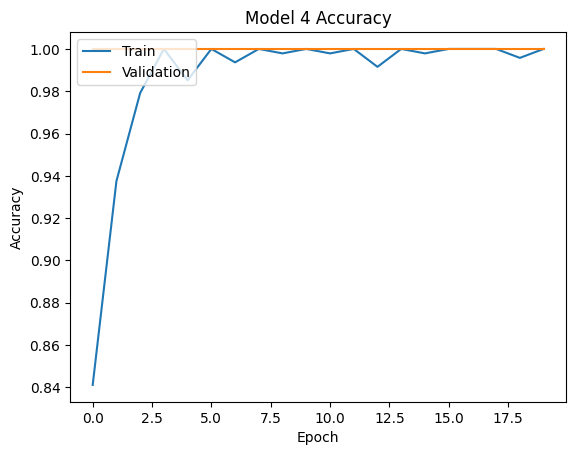

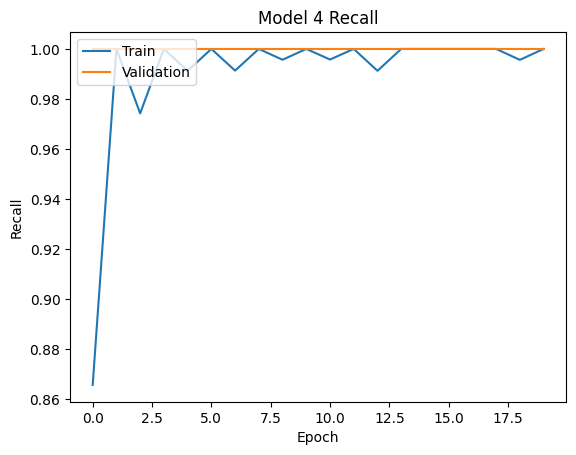

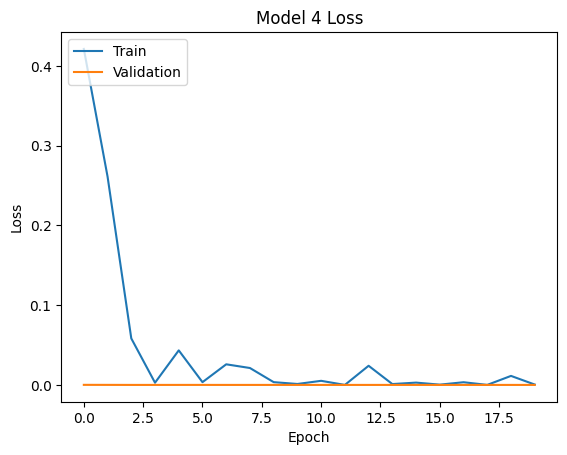

In [ ]:
# Plotting accuracy
plt.plot(history_4.history['accuracy']) #Code to plot the train metrics
plt.plot(history_4.history['val_accuracy']) #Code to plot the validation data metrics
plt.title('Model 4 Accuracy') #Code to define the title for the plot
plt.ylabel('Accuracy') #Code to define the label for the y-axis
plt.xlabel('Epoch') #Code to define the label for the x-axis
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

# Plotting Recall
plt.plot(history_4.history['Recall']) #Coode to plot the train metrics
plt.plot(history_4.history['val_Recall']) #Code to plot the validation data metrics
plt.title('Model 4 Recall') #Code to define the title for the plot
plt.ylabel('Recall') #Code to define the label for the y-axis
plt.xlabel('Epoch') #Code to define the label for the x-axis
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

# Plotting loss
plt.plot(history_4.history['loss']) #Code to plot the train metrics
plt.plot(history_4.history['val_loss']) #Code to plot the validation data metrics
plt.title('Model 4 Loss') #Code to define the title for the plot
plt.ylabel('Loss') #Code to define the label for the y-axis
plt.xlabel('Epoch') #Code to define the label for the x-axis
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

***Observations:***

**Accuracy Plot:** The training and validation accuracy for Model 4 start at a moderate level and quickly increase, converging to near 100% accuracy on both datasets within the first few epochs. This indicates that the pre-trained VGG-16 base combined with the additional feed-forward layers and data augmentation is very effective at learning to classify the images.

**Recall Plot:** The training and validation Recall plots show a similar trend to accuracy, starting at a moderate value and rapidly increasing to 100% within a few epochs. This suggests that Model 4 is also highly effective at identifying the positive class ("With Helmet").

**Loss Plot:** The training and validation loss for Model 4 decrease rapidly and converge to very low values, similar to the previous models. This indicates that the model is effectively minimizing the error during training and performing well on the validation set.

In [ ]:
# Evaluate Training performance metrics
model_4_train_perf = model_performance_classification(model_4, X_train_normalized,y_train)
print("Train performance metrics")
print(model_4_train_perf)

16/16 ━━━━━━━━━━━━━━━━━━━━ 4s 229ms/step
Train performance metrics
   Accuracy  Recall  Precision  F1 Score
0       1.0     1.0        1.0       1.0


16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 182ms/step


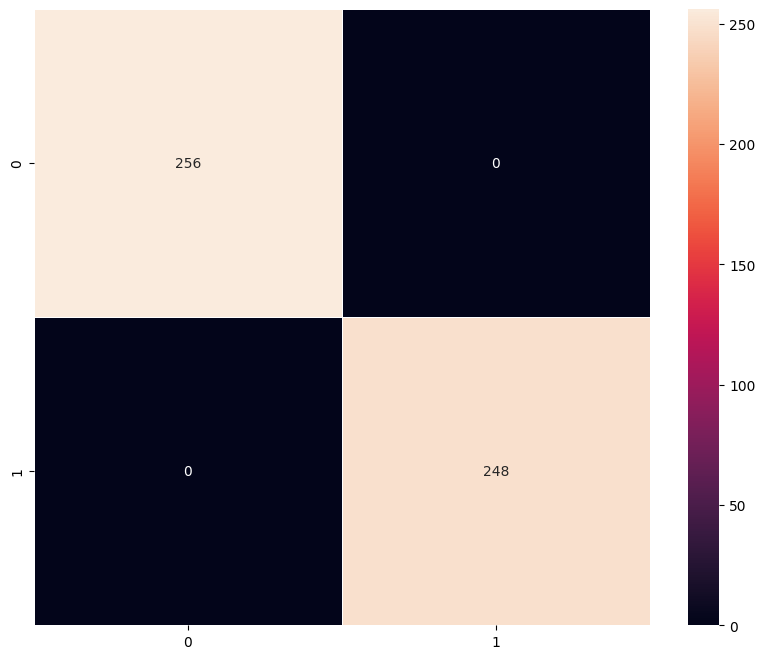

In [ ]:
# Plotting Confusion Matrix
plot_confusion_matrix(model_4,X_train_normalized,y_train)

***Observations:***

a) The **Model 4 Train performance metrics** indicates that Model 4 achieved perfect scores on the training dataset for all evaluated metrics.

b) **Model 4 Training Confusion Matrix:** This confusion matrix confirms that Model 4 correctly classified all 256 instances of "Without Helmet" and all 248 instances of "With Helmet" in the training dataset. There were no false positives or false negatives.

In [ ]:
# Evaluate Validation performance metrics
model_4_valid_perf = model_performance_classification(model_4, X_val_normalized,y_val)
print("Validation performance metrics")
print(model_4_valid_perf)

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 448ms/step
Validation performance metrics
   Accuracy  Recall  Precision  F1 Score
0       1.0     1.0        1.0       1.0


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 175ms/step


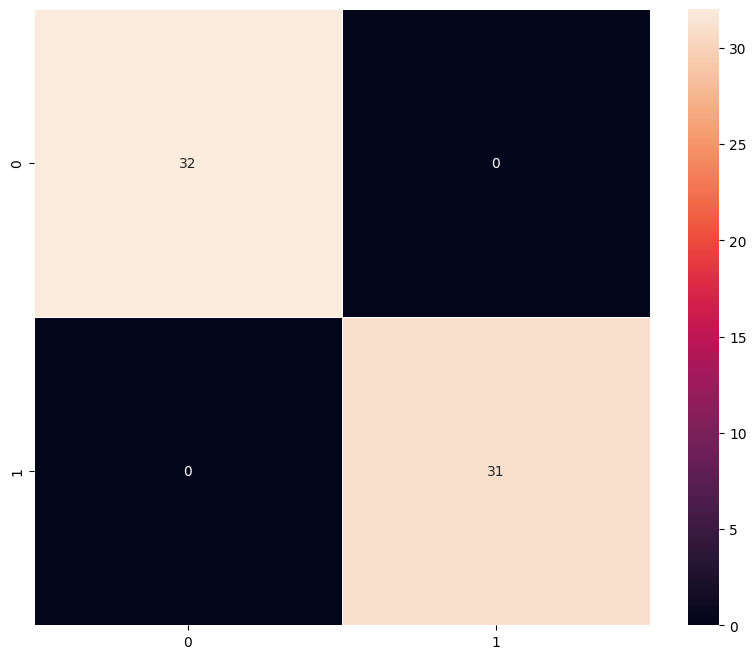

In [ ]:
# Plotting Confusion Matrix
plot_confusion_matrix(model_4,X_val_normalized,y_val)

***Observations:***

a) The **Model 4 Validation performance metrics** indicates that Model 4 achieved perfect scores on the training dataset for all evaluated metrics.

b) **Model 4 Validation Confusion Matrix:** This confusion matrix confirms that Model 4 correctly classified all 32 instances of "Without Helmet" and all 31 instances of "With Helmet" in the training dataset. There were no false positives or false negatives.

#### Visualizing the predictions

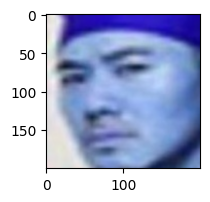

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
Predicted Label: 0
True Label: Label    0
Name: 625, dtype: int64


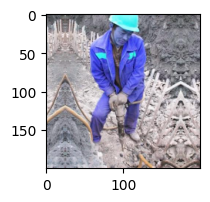

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
Predicted Label: 1
True Label: Label    1
Name: 115, dtype: int64


In [ ]:
# For index 40
plt.figure(figsize=(2,2))
plt.imshow(X_val[40]) #Code to define the index
plt.show()
prediction = model_2.predict(X_val_normalized[40].reshape(1,200,200,3)) #Code to define the index
predicted_label = prediction[0][0]>0.5  # Extract the predicted class label
print('Predicted Label:', 1 if predicted_label else 0)
true_label = y_val.iloc[40] #Code to define the index
print('True Label:', true_label)

# For index 50
plt.figure(figsize=(2,2))
plt.imshow(X_val[50]) #Code to define the index
plt.show()
prediction = model_2.predict(X_val_normalized[50].reshape(1,200,200,3)) #Code to define the index
predicted_label = prediction[0][0]>0.5  # Extract the predicted class label
print('Predicted Label:', 1 if predicted_label else 0)
true_label = y_val.iloc[50] #Code to define the index
print('True Label:', true_label)

***Observations:***

Model 4 is correctly predicting and classifying the "Without Helmet" and "With Helmet" sample images.

# **Model Performance Comparison and Final Model Selection**

In [ ]:
# Training performance comparison

models_train_comp_df = pd.concat(
    [
        model_1_train_perf.T,
        model_2_train_perf.T,
        model_3_train_perf.T,
        model_4_train_perf.T,
    ],
    axis=1,
)
models_train_comp_df.columns = [
    "Simple Convolutional Neural Network (CNN)","VGG-16 (Base)","VGG-16 (Base+FFNN)","VGG-16 (Base+FFNN+Data Aug)"
]

In [ ]:
models_valid_comp_df = pd.concat(
    [
        model_1_valid_perf.T,
        model_2_valid_perf.T,
        model_3_valid_perf.T,
        model_4_valid_perf.T

    ],
    axis=1,
)
models_valid_comp_df.columns = [
 "Simple Convolutional Neural Network (CNN)","VGG-16 (Base)","VGG-16 (Base+FFNN)","VGG-16 (Base+FFNN+Data Aug)"
]

In [ ]:
models_train_comp_df

,Simple Convolutional Neural Network (CNN),VGG-16 (Base),VGG-16 (Base+FFNN),VGG-16 (Base+FFNN+Data Aug)
Accuracy,1.0,1.0,1.0,1.0
Recall,1.0,1.0,1.0,1.0
Precision,1.0,1.0,1.0,1.0
F1 Score,1.0,1.0,1.0,1.0


In [ ]:
models_valid_comp_df

,Simple Convolutional Neural Network (CNN),VGG-16 (Base),VGG-16 (Base+FFNN),VGG-16 (Base+FFNN+Data Aug)
Accuracy,1.0,1.0,1.0,1.0
Recall,1.0,1.0,1.0,1.0
Precision,1.0,1.0,1.0,1.0
F1 Score,1.0,1.0,1.0,1.0


In [ ]:
models_train_comp_df - models_valid_comp_df

,Simple Convolutional Neural Network (CNN),VGG-16 (Base),VGG-16 (Base+FFNN),VGG-16 (Base+FFNN+Data Aug)
Accuracy,0.0,0.0,0.0,0.0
Recall,0.0,0.0,0.0,0.0
Precision,0.0,0.0,0.0,0.0
F1 Score,0.0,0.0,0.0,0.0


## Test Performance

*** Chosing the Best Model ***

Based on the training and validation performance, we observe that all four models achieved perfect scores (1.0 for Accuracy, Recall, Precision, and F1 Score) on both the training and validation datasets.

**Model 2 wins** on overall balance. Also, being a pre-trained model with a simpler architecture on top compared to Models 3 and 4, might be less prone to overfitting than the more complex models, especially given the small dataset size and also the below plot metrics.

**- Loss:** Converges cleanly with no oscillations.

**- Recall:** Hits 1.00 early and holds it perfectly.

**- Generalization:** No signs of overfitting or instability.

**Model 1 (Simple CNN)** was slower to reach optimal metrics — needing ~5 epochs to stabilize.

**Model 3 (VGG-16 (Base+FFNN)	)** is a close runner-up with ultra-fast convergence and flawless recall, but its abrupt perfection could hint at simplicity in data or heavy inductive bias.

**Model 4** (VGG-16 (Base+FFNN+Data Aug) deserves consistency and most robust and consistent performer


In [ ]:
# Evaluate Test Data performance
model_test_perf = model_performance_classification(model_2, X_test_normalized,y_test) #Best model chosen as Model_2 (VGG-16 Base)
model_test_perf

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 217ms/step


,Accuracy,Recall,Precision,F1 Score
0,1.0,1.0,1.0,1.0


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 183ms/step


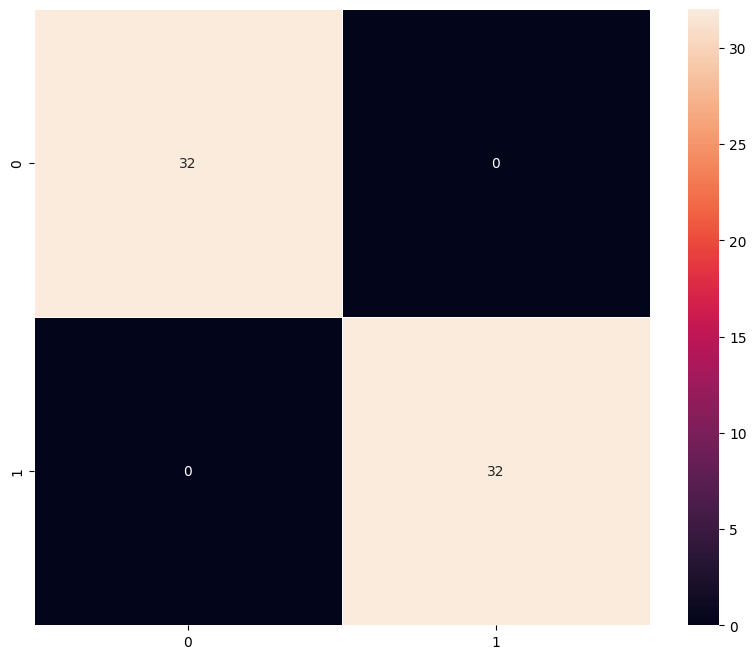

In [ ]:
# Plot Confusion Matrix for Test Data
plot_confusion_matrix(model_2, X_test_normalized,y_test) #Best model chosen as Model 2 (VGG - 16 Base)

***Observations on Test Data:**

1) 100% classification accuracy across both classes

2) Precision, Recall, and F1 = 1.00

3) Zero errors — the model distinguishes perfectly between classes ("With Helmet") and ("Without Helmet") based on the confusion matrix.




## Actionable Insights & Recommendations

***Actionable Insights:***

1) **All models achieved perfect scores** on the training and validation datasets, suggesting potential overfitting given the small dataset size.

2) **For Model 1 (Simple CNN)** , it recovers to perfection after early instability based on accuracy, recall and loss plots. We can edge cases or hard samples to verify resilience.

3) **For Model 2 (VGG - 16 Base)** , It shows early and smooth generalization to perfect scores based on accuracy, recall and loss plots. We can fine-tune on augmented or blurred inputs.

4) **For Model 3 (VGG - 16 Base+FFNN)** , It shows instant perfection, fastest convergence based on accuracy, recall and loss plots. We can test against adversarial inputs for true generalization

5) **For Model 4 (VGG - 16 Base+FFNN+Data Aug)** , It shows steady rise to perfect performance, no volatility based on accuracy, recall and loss plots. We can evaluate test on imbalanced or augmented datasets.

***Recommendations:***

1. **Increase the dataset size:** A larger and more diverse dataset is crucial to build a robust model that generalizes well to unseen images.
2. **Re-evaluate the data splitting and evaluation:** Double-check the data splitting process to ensure there's no data leakage between training, validation, and test sets. Consider using cross-validation if a larger dataset is not immediately available.
3. **Regularization techniques:** While dropout was added to Model 4, other techniques could be explored to mitigate overfitting, especially if the dataset size remains limited.
4. **Consider other architectures:** Experiment with other pre-trained models besides VGG-16 and fine-tune them on your dataset.
5. **Further data augmentation:** Explore a wider range of data augmentation techniques to increase the variability of the training data.
6. **Collect more diverse images:** Ensure the dataset includes images from various environments, lighting conditions, angles, and worker activities to better represent real-world scenarios.

<font size=5 color='blue'>Power Ahead!</font>
___